# Module 3 — Session 2

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Show first 5 rows just to confirm it loaded
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exercise 1: The Initial Investigation

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Initial Observations

1. The **Age** column has many missing values (only 714 non-null out of 891). This means any age-based analysis needs to consider missing data handling.
2. The **Cabin** column is missing most of its values (only 204 non-null). This column may be unreliable for analysis unless we perform additional data cleaning.
3. The **Parch** column (parents/children aboard) shows that most passengers traveled without parents or children (median = 0).
4. The fare price varies widely — from 0 to over 512, meaning the passenger socioeconomic distribution is very large.


## Exercise 2 — Univariate Analysis

### Exercise 2.1 — Age Distribution

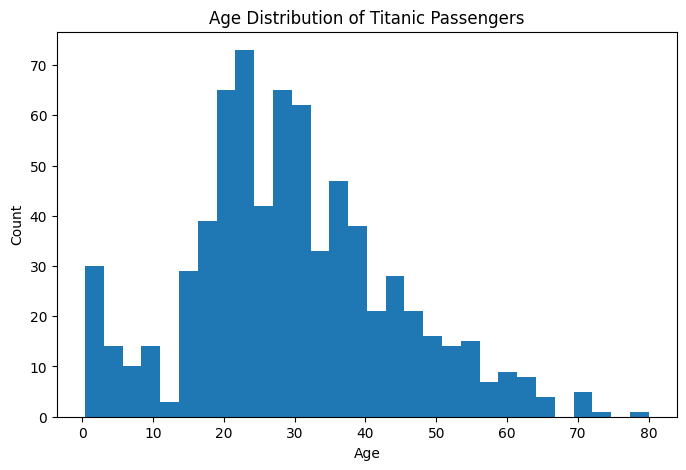

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=30)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Exercise 2.2 — Sex Distribution

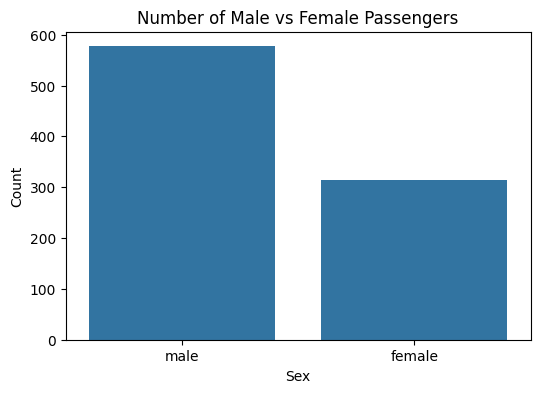

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex')
plt.title("Number of Male vs Female Passengers")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


### Exercise 2.3 — Passenger Class Distribution

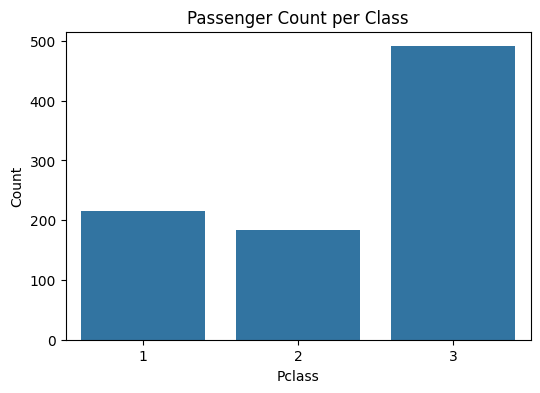

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass')
plt.title("Passenger Count per Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()


## Exercise 3: Bivariate Analysis

### Exercise 3.1 — Survival by Passenger Class

In [25]:
ct_pclass = pd.crosstab(df['Pclass'], df['Survived'])
ct_pclass

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


#### Stacked Bar Chart — Survival by Class

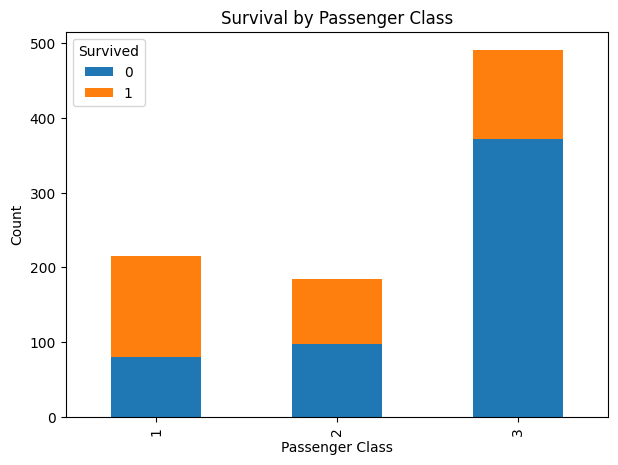

In [26]:
ct_pclass.plot(kind='bar', stacked=True, figsize=(7,5))
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

### Exercise 3.2 — Survival by Sex

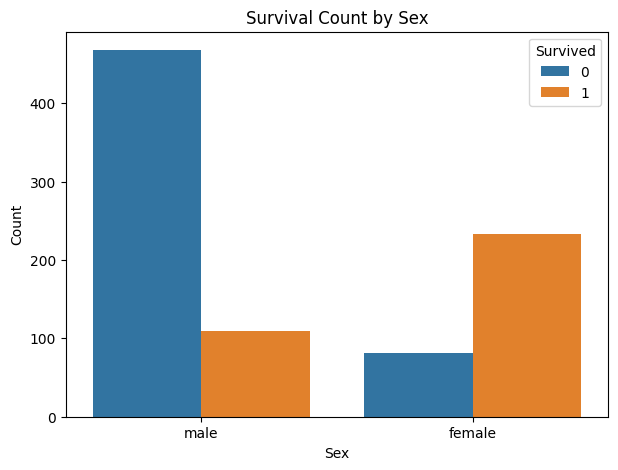

In [27]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


### Exercise 3.3 — Relationship Between Age and Fare

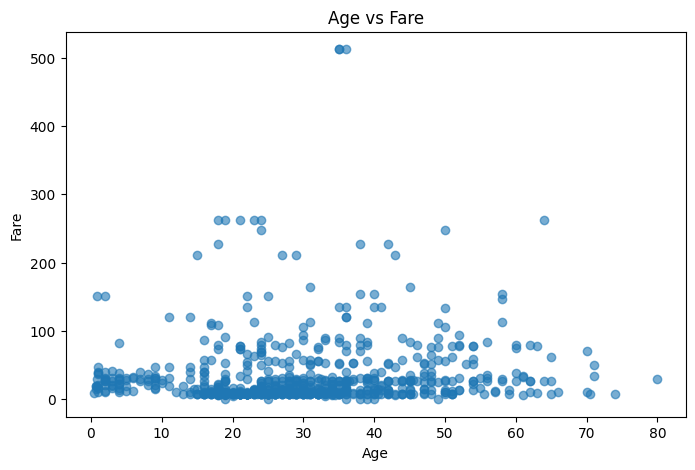

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Fare'], alpha=0.6)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


### Exercise 3.4 — Correlation Heatmap


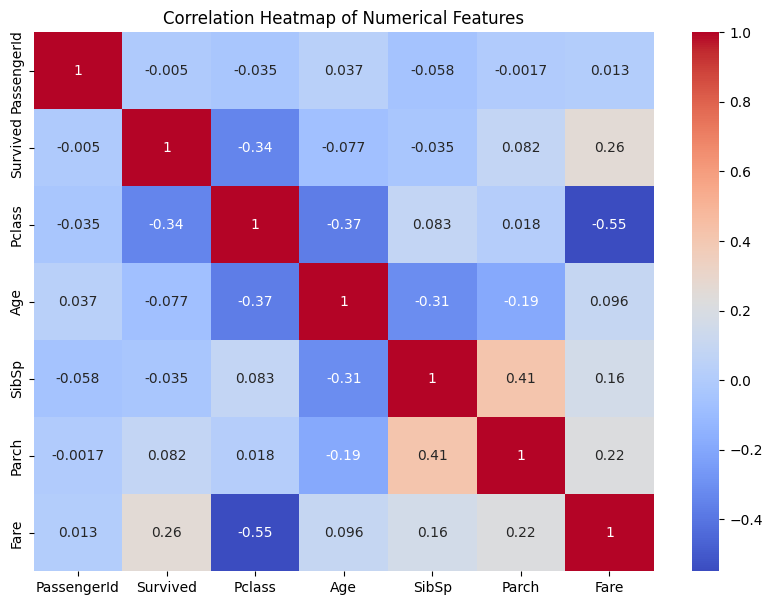

In [29]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()